Import Libraries

In [92]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [93]:
import joblib

X_train = joblib.load("../src/data/processed/X_train.pkl")
X_test = joblib.load("../src/data/processed/X_test.pkl")
y_train = joblib.load("../src/data/processed/y_train.pkl")
y_test = joblib.load("../src/data/processed/y_test.pkl")

print(X_train.shape)
print(X_test.shape)

(32940, 53)
(8236, 53)


Logistic Regression Model

In [94]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Logistic Regression

In [95]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Accuracy Score: {accuracy:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 90.93%

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236


Confusion Matrix
[[7097  211]
 [ 536  392]]


onfusion Matrix Visualization

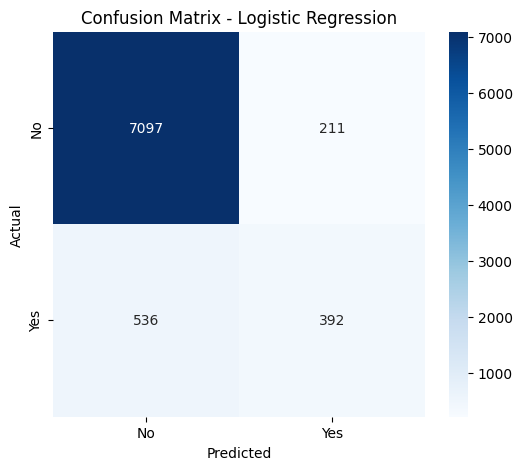

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

ROC AUC Score, Precision, Recall, F1 Score

In [97]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob) * 100

print(f"ROC AUC Score: {roc_auc:.2f}%")

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

ROC AUC Score: 93.90%
Precision : 65.01%
Recall    : 42.24%
F1 Score  : 51.21%


Decision Tree Classifier

In [98]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

Decision Tree Evaluation

In [99]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy_dt = accuracy_score(y_test, y_pred_dt) * 100

print(f"Accuracy Score: {accuracy_dt:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy Score: 89.23%

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7308
           1       0.52      0.52      0.52       928

    accuracy                           0.89      8236
   macro avg       0.73      0.73      0.73      8236
weighted avg       0.89      0.89      0.89      8236


Confusion Matrix
[[6865  443]
 [ 444  484]]


Decision Tree Confusion Matrix

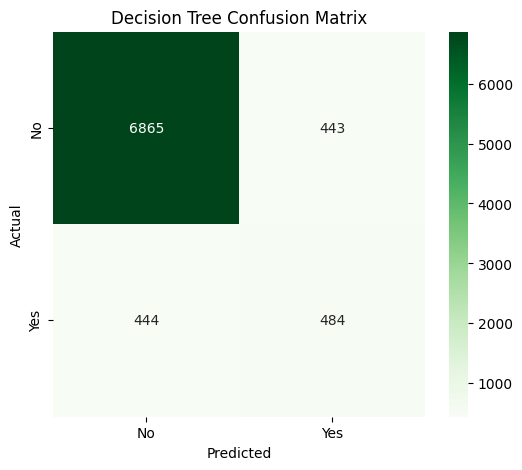

In [100]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Decision Tree ROC-AUC, Precision, Recall, F1 Score

In [101]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt) * 100

print(f"ROC AUC Score: {roc_auc_dt:.2f}%")

from sklearn.metrics import precision_score, recall_score, f1_score

precision_dt = precision_score(y_test, y_pred_dt) * 100
recall_dt = recall_score(y_test, y_pred_dt) * 100
f1_dt = f1_score(y_test, y_pred_dt) * 100

print(f"Precision : {precision_dt:.2f}%")
print(f"Recall    : {recall_dt:.2f}%")
print(f"F1 Score  : {f1_dt:.2f}%")

ROC AUC Score: 73.05%
Precision : 52.21%
Recall    : 52.16%
F1 Score  : 52.18%


Random Forest Classifier

In [102]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Random Forest Evaluation

In [103]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100

print(f"Accuracy Score: {accuracy_rf:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy Score: 91.16%

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7308
           1       0.64      0.48      0.55       928

    accuracy                           0.91      8236
   macro avg       0.79      0.72      0.75      8236
weighted avg       0.90      0.91      0.91      8236


Confusion Matrix
[[7061  247]
 [ 481  447]]


Random Forest Confusion Matrix

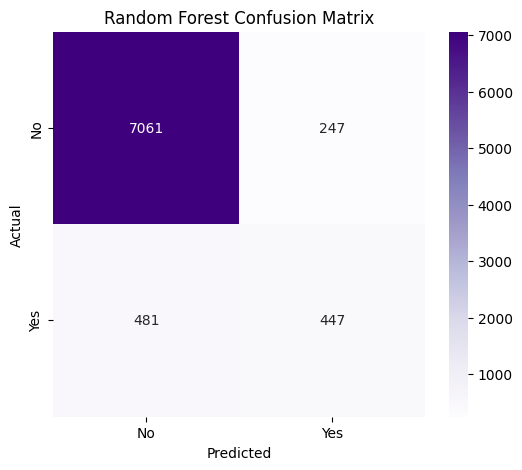

In [104]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest ROC-AUC, Precision, Recall, F1 Score

In [105]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf) * 100

print(f"ROC AUC Score: {roc_auc_rf:.2f}%")

from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf) * 100
recall_rf = recall_score(y_test, y_pred_rf) * 100
f1_rf = f1_score(y_test, y_pred_rf) * 100

print(f"Precision : {precision_rf:.2f}%")
print(f"Recall    : {recall_rf:.2f}%")
print(f"F1 Score  : {f1_rf:.2f}%")

ROC AUC Score: 94.38%
Precision : 64.41%
Recall    : 48.17%
F1 Score  : 55.12%


In [106]:
import joblib

feature_names = joblib.load("../models/feature_names.pkl")

Feature Importance

In [107]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,duration,0.299358
8,euribor3m,0.095312
0,age,0.086418
9,nr.employed,0.053030
2,campaign,0.041863
3,pdays,0.029677
7,cons.conf.idx,0.028955
52,poutcome_success,0.024109
5,emp.var.rate,0.023571
6,cons.price.idx,0.021472


Top 10 Important Features

In [108]:

top_10_features = feature_importance.head(10).copy()

top_10_features.reset_index(drop=True, inplace=True)

top_10_features

,Feature,Importance
0,duration,0.299358
1,euribor3m,0.095312
2,age,0.086418
3,nr.employed,0.053030
4,campaign,0.041863
5,pdays,0.029677
6,cons.conf.idx,0.028955
7,poutcome_success,0.024109
8,emp.var.rate,0.023571
9,cons.price.idx,0.021472


Top 10 Important Features Plot

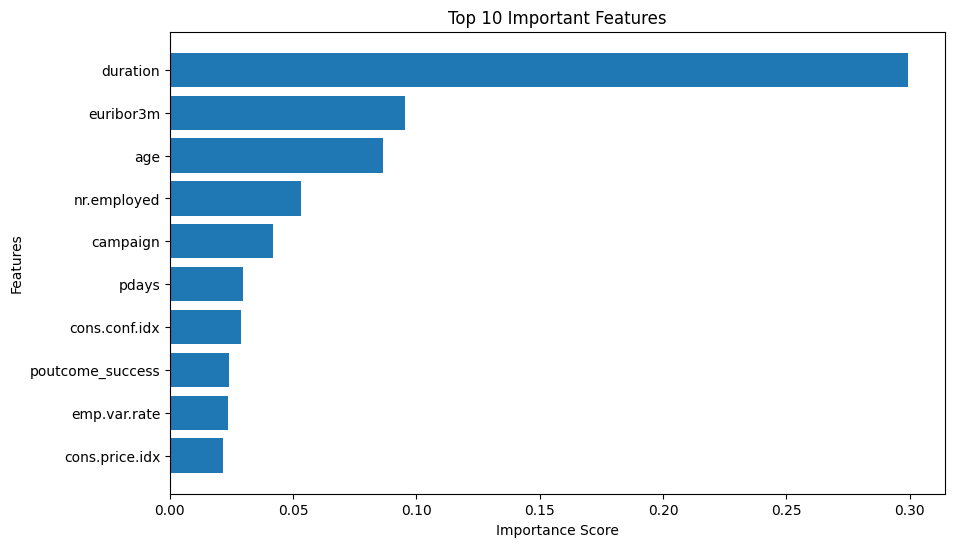

In [109]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

Save Models

In [110]:
import joblib

joblib.dump(log_model, "../models/logistic_regression.pkl")
joblib.dump(dt_model, "../models/decision_tree.pkl")
joblib.dump(rf_model, "../models/random_forest.pkl")

print("All models saved successfully.")

All models saved successfully.


Save Feature Importance

In [111]:
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


Model Building Summary

In [112]:
print("MODEL BUILDING COMPLETED")
print(f"Logistic Regression Accuracy Score: {accuracy:.2f}%")
print(f"Decision Tree Accuracy : {accuracy_dt:.2f}%")
print(f"Random Forest Accuracy Score: {accuracy_rf:.2f}%")



MODEL BUILDING COMPLETED
Logistic Regression Accuracy Score: 90.93%
Decision Tree Accuracy : 89.23%
Random Forest Accuracy Score: 91.16%


Create Model Comparison Table

In [113]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy (%)": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision (%)": [
        precision,
        precision_dt,
        precision_rf
    ],

    "Recall (%)": [
        recall,
        recall_dt,
        recall_rf
    ],

    "F1 Score (%)": [
        f1,
        f1_dt,
        f1_rf
    ],

    "ROC AUC (%)": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]

})

comparison

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC (%)
0,Logistic Regression,90.930063,65.008292,42.241379,51.208361,93.898721
1,Decision Tree,89.230209,52.211435,52.155172,52.183288,73.046661
2,Random Forest,91.160758,64.409222,48.168103,55.117139,94.381062


Save Comparison Table

In [114]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.
